# 02 - Annotation Analysis

## AI-Powered Runway FOD Detection & Safety Alert System

### Objective

In this notebook, we will study the object-detection annotations in detail.

We will analyze:

- FOD class distribution
- Class imbalance
- Bounding box width and height
- Bounding box area
- Bounding box aspect ratio
- Object position inside the image
- Multiple objects in one image
- Occluded objects
- Truncated objects
- Difficult objects
- Weather and light conditions
- Annotation examples

This notebook focuses specifically on the annotations and bounding boxes.


## 1. Import Libraries

In [39]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load the Processed Annotation Dataset

In [40]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "fod_annotations.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)


Dataset shape: (34472, 25)


## 3. Basic Annotation Overview

In [41]:
print("Number of annotation rows:", len(df))
print("Number of unique images:", df["image_id"].nunique())
print("Number of FOD classes:", df["class_name"].nunique())

print("\nClass names:")
print(sorted(df["class_name"].unique()))


Number of annotation rows: 34472
Number of unique images: 33793
Number of FOD classes: 31

Class names:
['AdjustableClamp', 'AdjustableWrench', 'Battery', 'Bolt', 'BoltNutSet', 'BoltWasher', 'ClampPart', 'Cutter', 'FuelCap', 'Hammer', 'Hose', 'Label', 'LuggagePart', 'LuggageTag', 'MetalPart', 'MetalSheet', 'Nail', 'Nut', 'PaintChip', 'Pen', 'PlasticPart', 'Pliers', 'Rock', 'Screw', 'Screwdriver', 'SodaCan', 'Tape', 'Washer', 'Wire', 'Wood', 'Wrench']


## 4. Objects Per Image

In [42]:
objects_per_image = df.groupby("image_id").size()

print("Average objects per image:", objects_per_image.mean())
print("Median objects per image:", objects_per_image.median())
print("Maximum objects in one image:", objects_per_image.max())
print("Minimum objects in one image:", objects_per_image.min())


Average objects per image: 1.0200929186517917
Median objects per image: 1.0
Maximum objects in one image: 2
Minimum objects in one image: 1


In [43]:
object_count_distribution = objects_per_image.value_counts().sort_index()

print("Objects per image:")
print(object_count_distribution)


Objects per image:
1    33114
2      679
Name: count, dtype: int64


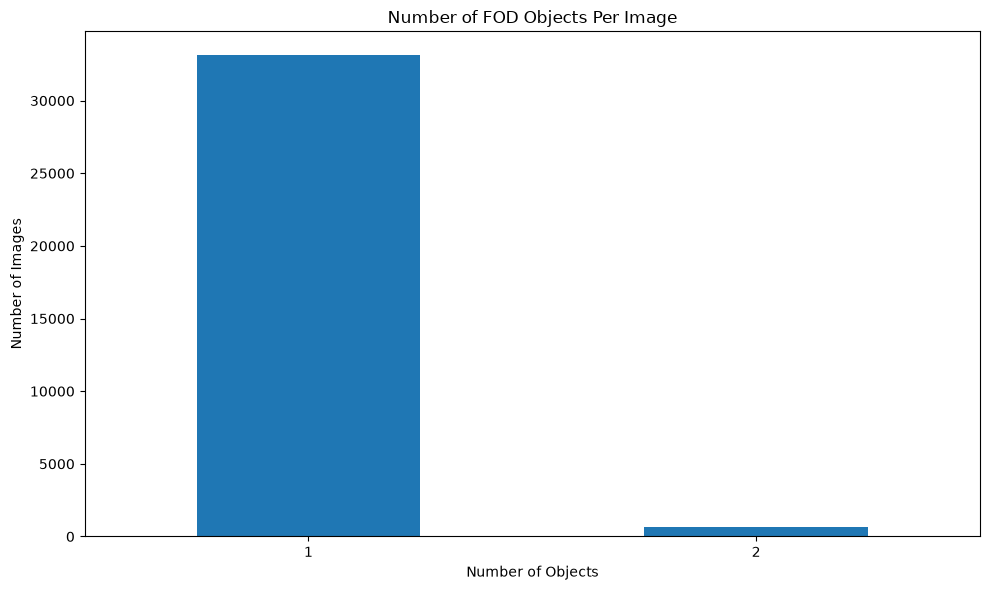

In [44]:
plt.figure(figsize=(10, 6))

object_count_distribution.plot(kind="bar")

plt.title("Number of FOD Objects Per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. FOD Class Distribution

In [45]:
class_counts = df["class_name"].value_counts()

print(class_counts)


class_name
Bolt                3300
Pliers              2884
Wrench              2568
Washer              2139
Wire                2138
PlasticPart         2008
LuggageTag          1686
Cutter              1352
Label               1310
Nut                 1303
Nail                1193
Battery             1059
BoltWasher          1017
MetalPart            970
PaintChip            968
SodaCan              950
ClampPart            917
Screwdriver          811
Hammer               760
LuggagePart          738
Rock                 662
FuelCap              548
AdjustableClamp      544
BoltNutSet           514
Pen                  483
AdjustableWrench     472
MetalSheet           394
Hose                 294
Wood                 206
Screw                157
Tape                 127
Name: count, dtype: int64


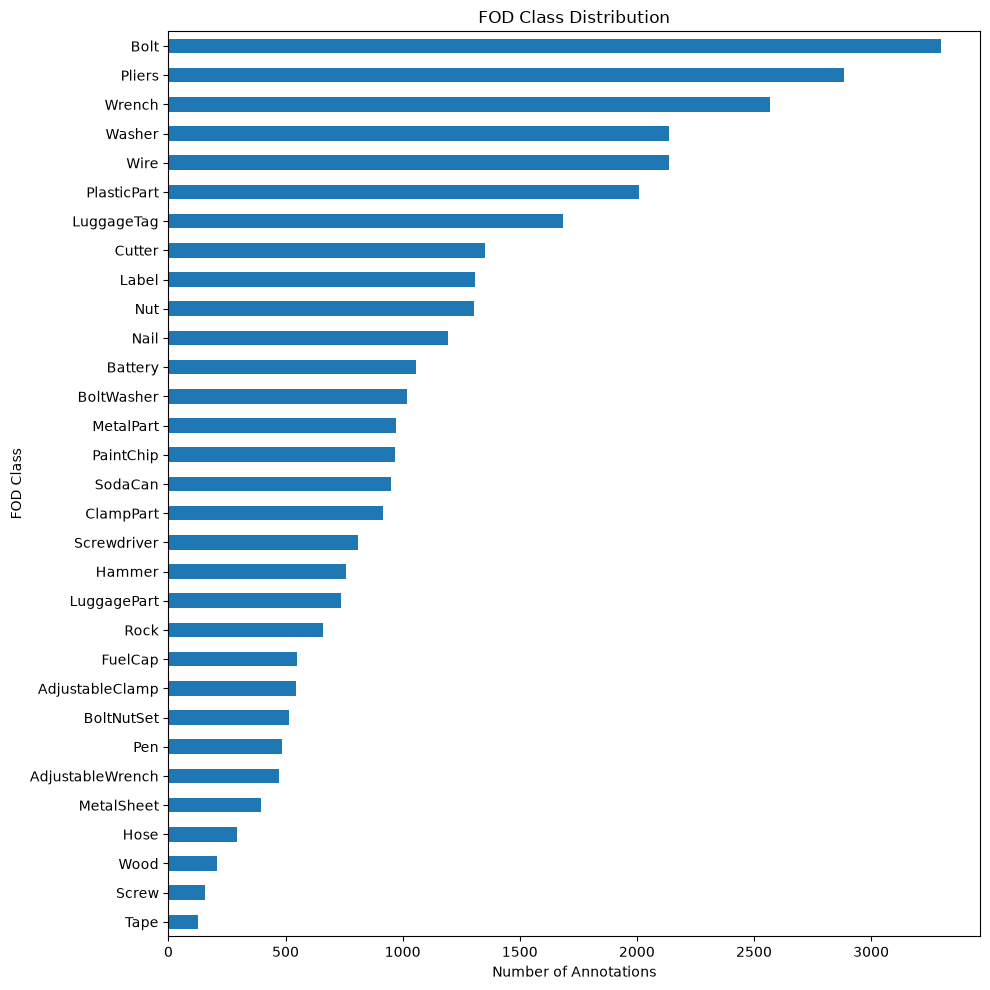

In [46]:
plt.figure(figsize=(10, 10))

class_counts.sort_values().plot(kind="barh")

plt.title("FOD Class Distribution")
plt.xlabel("Number of Annotations")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 6. Class Imbalance

In [47]:
most_common_class = class_counts.max()
least_common_class = class_counts.min()

print("Most common class count:", most_common_class)
print("Least common class count:", least_common_class)
print(
    "Most common / least common ratio:",
    most_common_class / least_common_class
)


Most common class count: 3300
Least common class count: 127
Most common / least common ratio: 25.984251968503937


In [48]:
class_percentage = (
    class_counts / class_counts.sum() * 100
)

class_percentage = class_percentage.sort_values(ascending=False)

print("Class percentage:")
print(class_percentage)


Class percentage:
class_name
Bolt                9.572987
Pliers              8.366210
Wrench              7.449524
Washer              6.205036
Wire                6.202135
PlasticPart         5.825017
LuggageTag          4.890926
Cutter              3.922024
Label               3.800186
Nut                 3.779879
Nail                3.460780
Battery             3.072058
BoltWasher          2.950220
MetalPart           2.813878
PaintChip           2.808076
SodaCan             2.755860
ClampPart           2.660130
Screwdriver         2.352634
Hammer              2.204688
LuggagePart         2.140868
Rock                1.920399
FuelCap             1.589696
AdjustableClamp     1.578092
BoltNutSet          1.491065
Pen                 1.401137
AdjustableWrench    1.369227
MetalSheet          1.142957
Hose                0.852866
Wood                0.597586
Screw               0.455442
Tape                0.368415
Name: count, dtype: float64


## 7. Bounding Box Width and Height

In [49]:
print("Normalized bounding box width:")
print(df["box_width"].describe())

print("\nNormalized bounding box height:")
print(df["box_height"].describe())


Normalized bounding box width:
count    34472.000000
mean         0.209388
std          0.174303
min          0.011242
25%          0.077320
50%          0.161492
75%          0.290778
max          1.000000
Name: box_width, dtype: float64

Normalized bounding box height:
count    34472.000000
mean         0.274412
std          0.210190
min          0.011131
25%          0.107855
50%          0.216074
75%          0.398540
max          1.000000
Name: box_height, dtype: float64


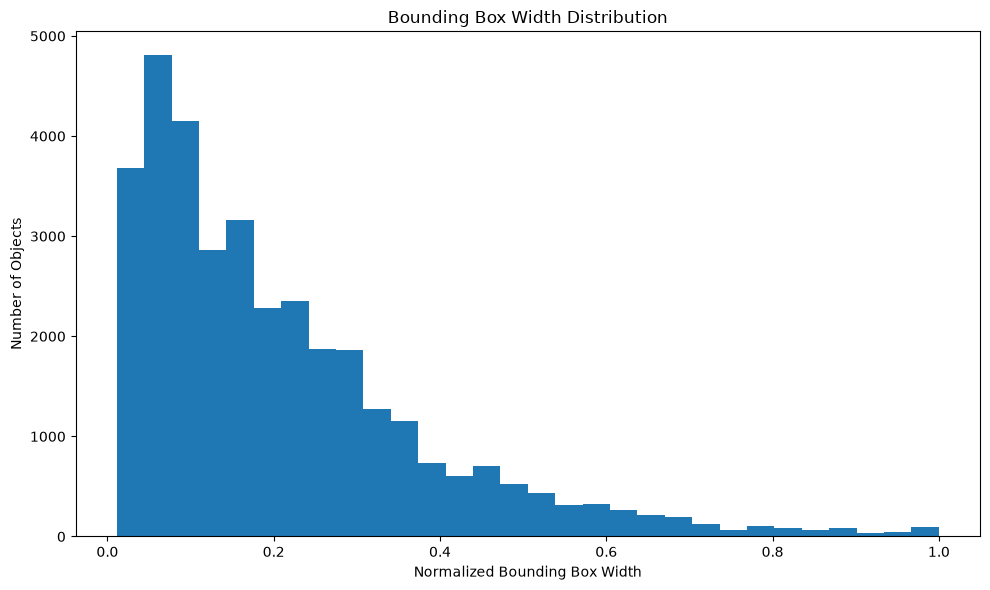

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(df["box_width"], bins=30)

plt.title("Bounding Box Width Distribution")
plt.xlabel("Normalized Bounding Box Width")
plt.ylabel("Number of Objects")

plt.tight_layout()
plt.show()


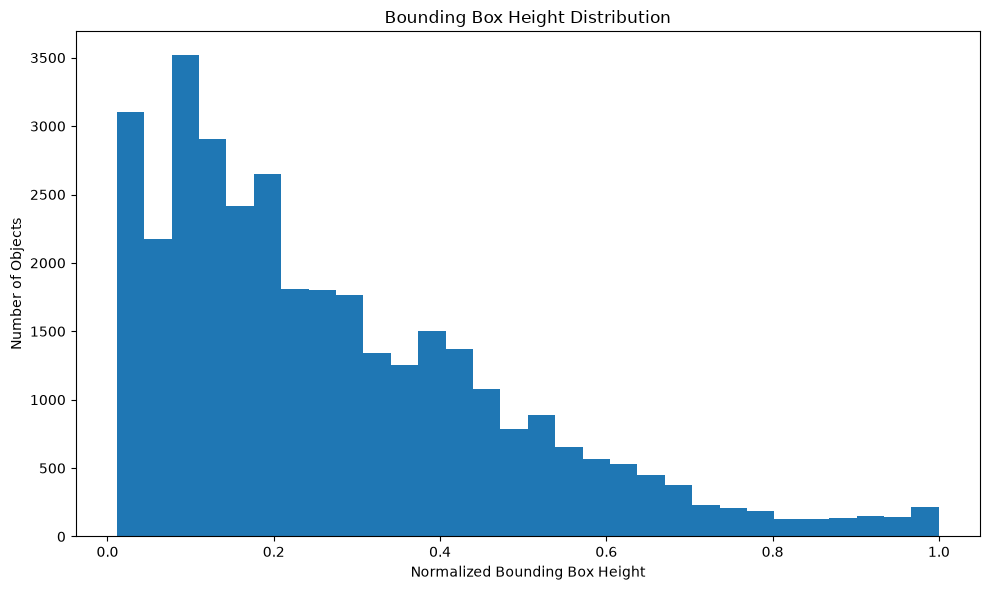

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(df["box_height"], bins=30)

plt.title("Bounding Box Height Distribution")
plt.xlabel("Normalized Bounding Box Height")
plt.ylabel("Number of Objects")

plt.tight_layout()
plt.show()


## 8. Bounding Box Area

In [52]:
df["box_area"] = df["box_width"] * df["box_height"]

print("Bounding box area:")
print(df["box_area"].describe())


Bounding box area:
count    34472.000000
mean         0.078659
std          0.108185
min          0.000238
25%          0.009356
50%          0.036121
75%          0.102903
max          0.864285
Name: box_area, dtype: float64


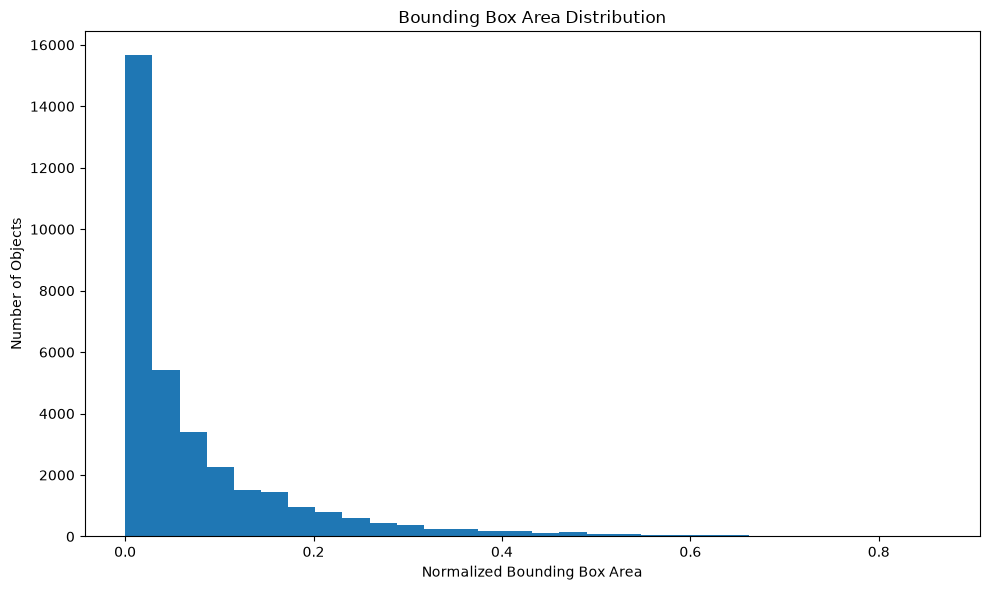

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(df["box_area"], bins=30)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Normalized Bounding Box Area")
plt.ylabel("Number of Objects")

plt.tight_layout()
plt.show()


## 9. Bounding Box Aspect Ratio

In [54]:
df["aspect_ratio"] = (
    df["box_width"] / df["box_height"]
)

print("Aspect ratio:")
print(df["aspect_ratio"].describe())


Aspect ratio:
count    34472.000000
mean         0.982083
std          0.933374
min          0.087163
25%          0.528119
50%          0.711743
75%          1.279387
max         14.141404
Name: aspect_ratio, dtype: float64


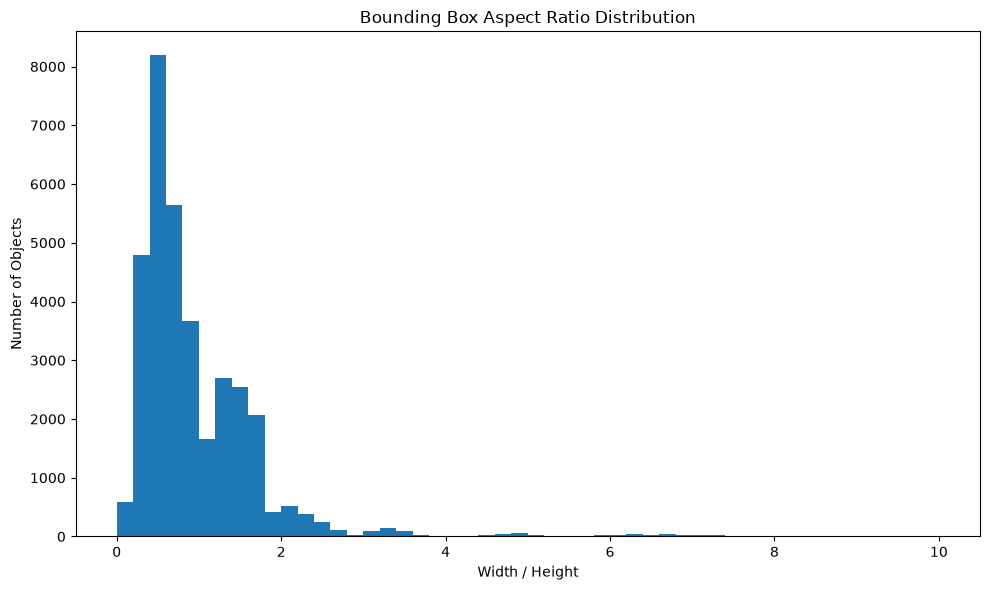

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["aspect_ratio"],
    bins=50,
    range=(0, 10)
)

plt.title("Bounding Box Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.ylabel("Number of Objects")

plt.tight_layout()
plt.show()


## 10. Object Position Inside the Image

In [56]:
print("X center:")
print(df["x_center"].describe())

print("\nY center:")
print(df["y_center"].describe())


X center:
count    34472.000000
mean         0.499440
std          0.140682
min          0.009088
25%          0.445406
50%          0.502887
75%          0.563482
max          0.988802
Name: x_center, dtype: float64

Y center:
count    34472.000000
mean         0.497695
std          0.188319
min          0.007653
25%          0.388803
50%          0.502729
75%          0.598830
max          0.989852
Name: y_center, dtype: float64


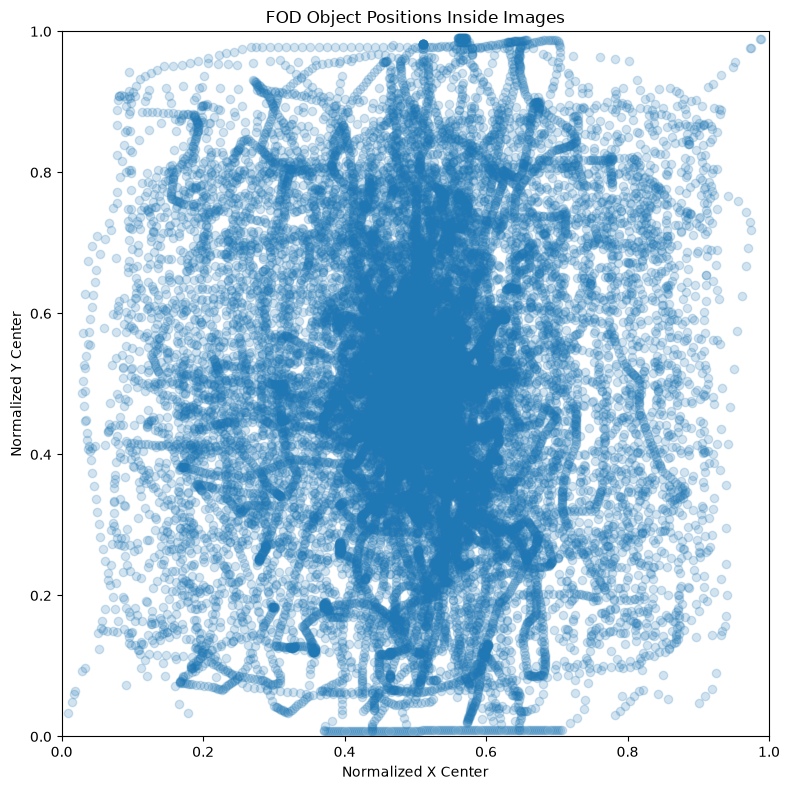

In [57]:
plt.figure(figsize=(8, 8))

plt.scatter(
    df["x_center"],
    df["y_center"],
    alpha=0.2
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.title("FOD Object Positions Inside Images")
plt.xlabel("Normalized X Center")
plt.ylabel("Normalized Y Center")

plt.tight_layout()
plt.show()


## 11. Small, Medium and Large Objects

For a simple dataset-level analysis, we divide objects by normalized bounding-box area.

These thresholds are only for exploratory analysis. They are not the model's official detection thresholds.

- Small: area < 0.01
- Medium: 0.01 to 0.10
- Large: area > 0.10


In [58]:
def get_object_size(area):
    if area < 0.01:
        return "Small"
    elif area <= 0.10:
        return "Medium"
    else:
        return "Large"


df["object_size"] = df["box_area"].apply(get_object_size)

print(df["object_size"].value_counts())


object_size
Medium    16556
Small      9057
Large      8859
Name: count, dtype: int64


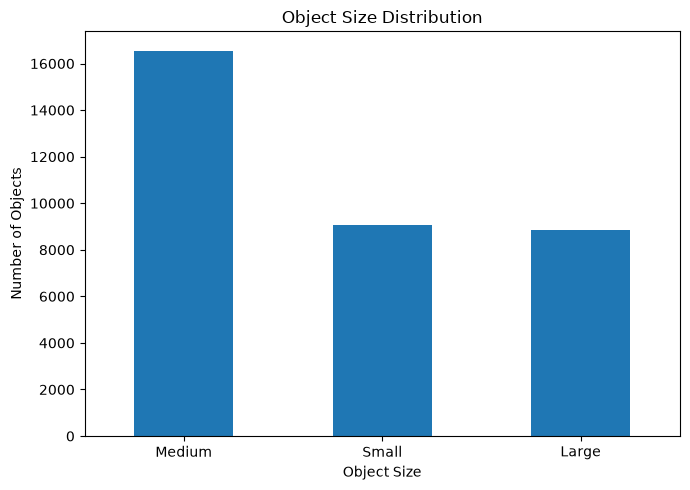

In [59]:
plt.figure(figsize=(7, 5))

df["object_size"].value_counts().plot(kind="bar")

plt.title("Object Size Distribution")
plt.xlabel("Object Size")
plt.ylabel("Number of Objects")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Object Size by FOD Class

In [60]:
object_size_by_class = pd.crosstab(
    df["class_name"],
    df["object_size"]
)

object_size_by_class


object_size,Large,Medium,Small
class_name,,,
AdjustableClamp,110,432,2
AdjustableWrench,336,108,28
Battery,10,519,530
Bolt,12,1682,1606
BoltNutSet,0,301,213
BoltWasher,0,359,658
ClampPart,238,540,139
Cutter,663,656,33
FuelCap,40,450,58


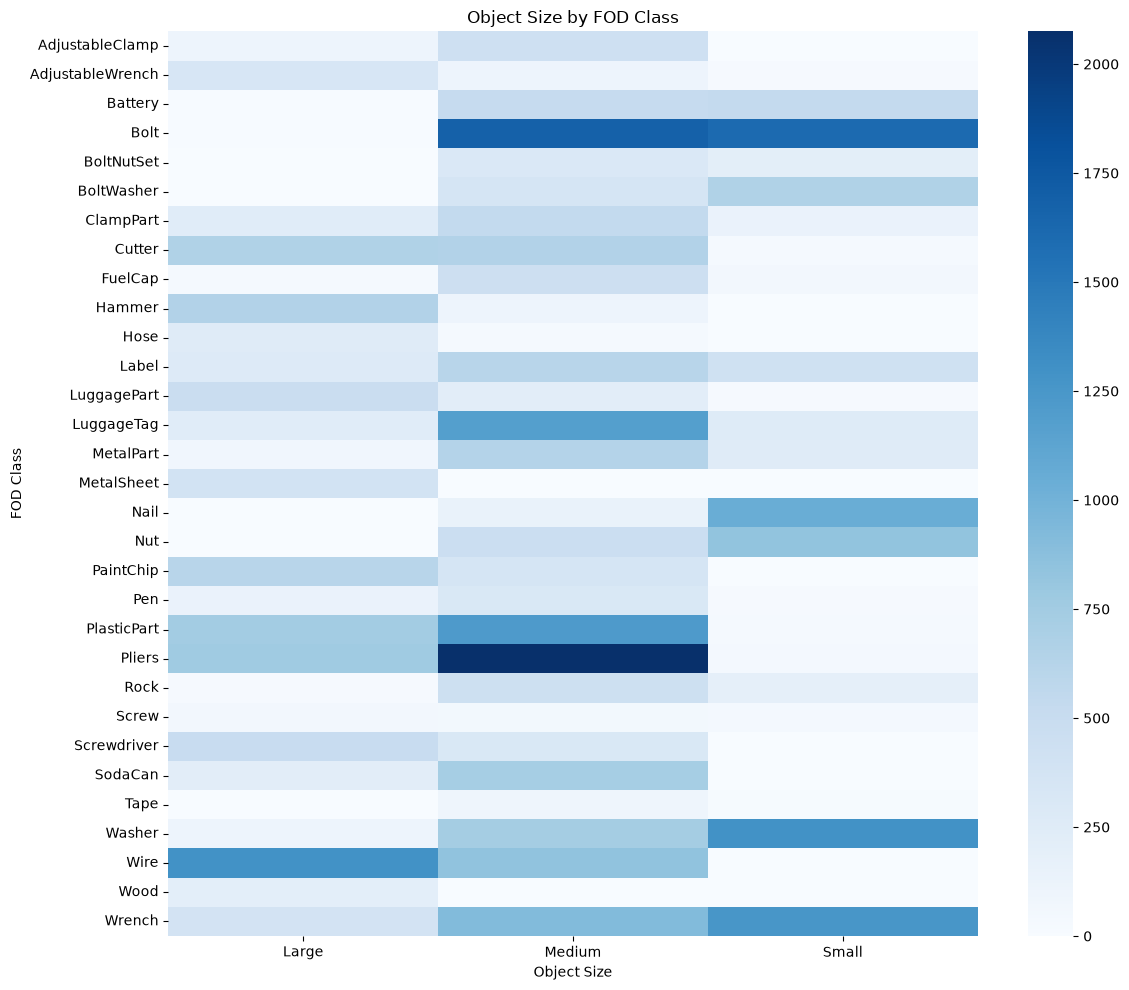

In [61]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    object_size_by_class,
    annot=False,
    cmap="Blues"
)

plt.title("Object Size by FOD Class")
plt.xlabel("Object Size")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 13. Occluded Objects

In [62]:
print("Occluded values:")
print(df["occluded"].value_counts(dropna=False))


Occluded values:
occluded
0    34472
Name: count, dtype: int64


In [63]:
occluded_percentage = (
    df["occluded"]
    .value_counts(normalize=True, dropna=False)
    * 100
)

print("Occluded percentage:")
print(occluded_percentage)


Occluded percentage:
occluded
0    100.0
Name: proportion, dtype: float64


## 14. Truncated Objects

In [64]:
print("Truncated values:")
print(df["truncated"].value_counts(dropna=False))


Truncated values:
truncated
0    34472
Name: count, dtype: int64


In [65]:
truncated_percentage = (
    df["truncated"]
    .value_counts(normalize=True, dropna=False)
    * 100
)

print("Truncated percentage:")
print(truncated_percentage)


Truncated percentage:
truncated
0    100.0
Name: proportion, dtype: float64


## 15. Difficult Objects

In [66]:
print("Difficult values:")
print(df["difficult"].value_counts(dropna=False))


Difficult values:
difficult
0    34472
Name: count, dtype: int64


In [67]:
difficult_percentage = (
    df["difficult"]
    .value_counts(normalize=True, dropna=False)
    * 100
)

print("Difficult percentage:")
print(difficult_percentage)


Difficult percentage:
difficult
0    100.0
Name: proportion, dtype: float64


## 16. Weather vs FOD Class

In [68]:
weather_class = pd.crosstab(
    df["class_name"],
    df["weather_label"]
)

weather_class


weather_label,Dry,Wet
class_name,,
AdjustableClamp,544,0
AdjustableWrench,472,0
Battery,359,700
Bolt,3300,0
BoltNutSet,514,0
BoltWasher,276,741
ClampPart,799,118
Cutter,514,838
FuelCap,342,206


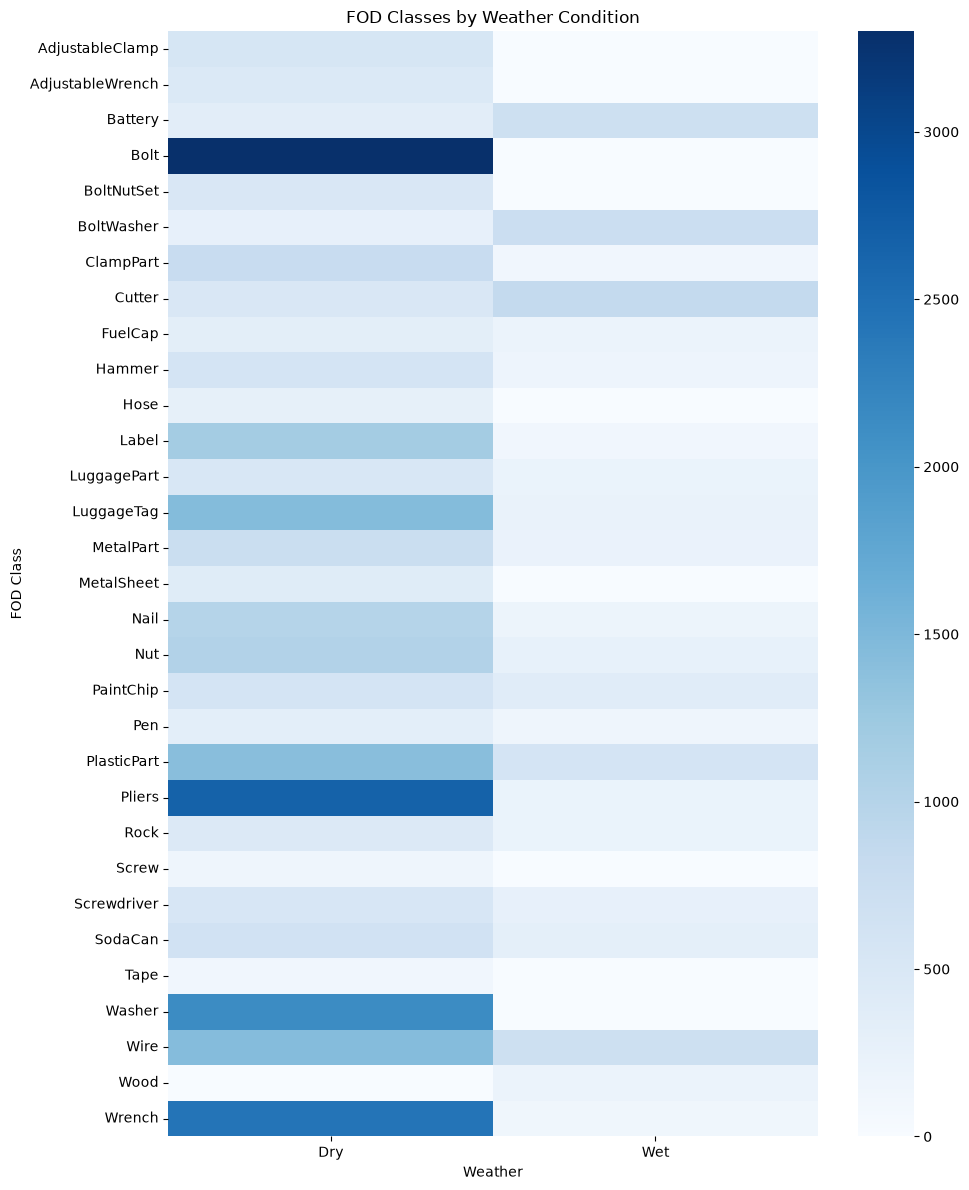

In [69]:
plt.figure(figsize=(10, 12))

sns.heatmap(
    weather_class,
    annot=False,
    cmap="Blues"
)

plt.title("FOD Classes by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 17. Light Condition vs FOD Class

In [70]:
light_class = pd.crosstab(
    df["class_name"],
    df["light_label"]
)

light_class


light_label,Bright,Dark,Dim
class_name,,,
AdjustableClamp,544,0,0
AdjustableWrench,472,0,0
Battery,0,173,886
Bolt,3118,182,0
BoltNutSet,514,0,0
BoltWasher,134,0,883
ClampPart,129,328,460
Cutter,150,188,1014
FuelCap,119,0,429


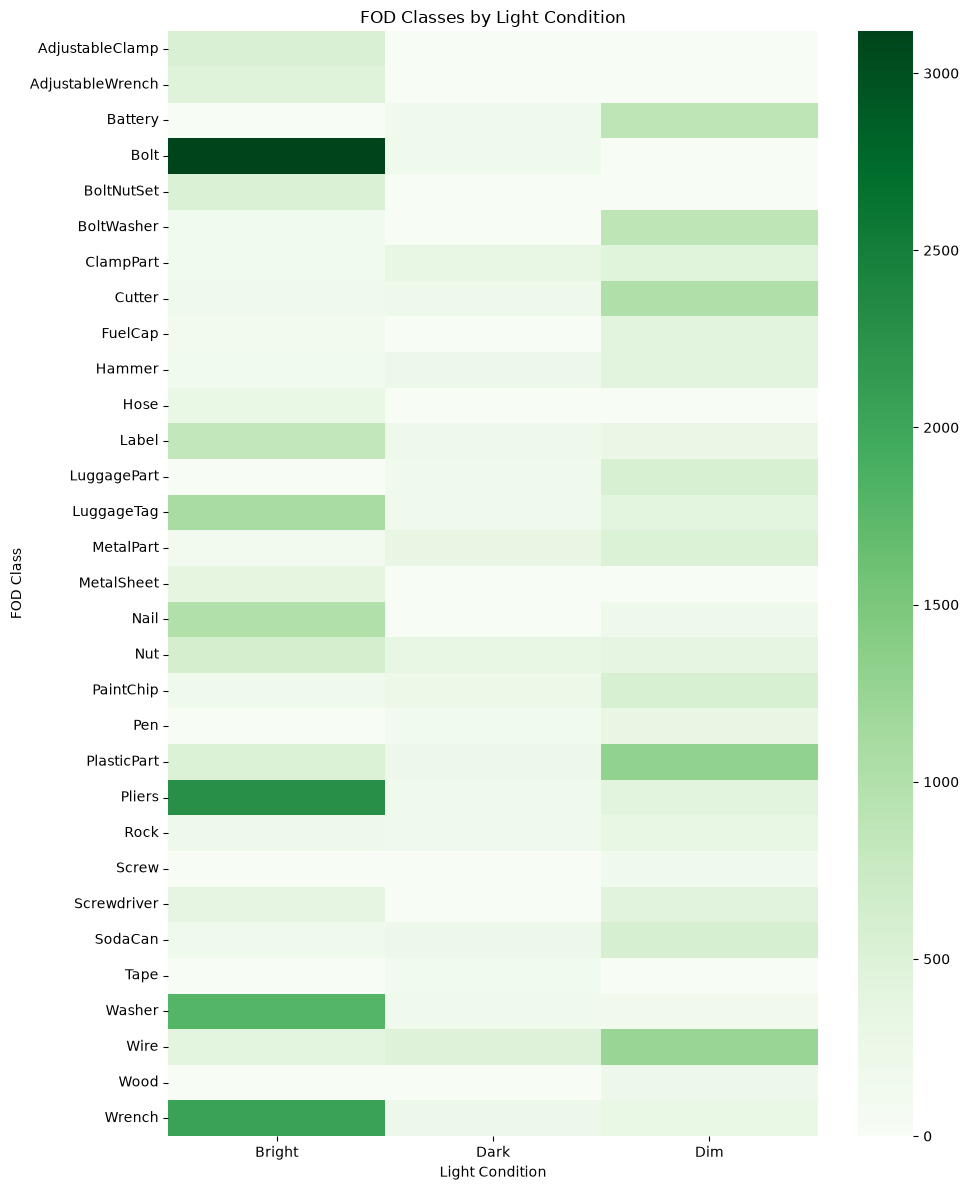

In [71]:
plt.figure(figsize=(10, 12))

sns.heatmap(
    light_class,
    annot=False,
    cmap="Greens"
)

plt.title("FOD Classes by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("FOD Class")

plt.tight_layout()
plt.show()


## 18. FOD Class and Average Bounding Box Size

In [72]:
class_box_summary = (
    df.groupby("class_name")
    .agg(
        average_width=("box_width", "mean"),
        average_height=("box_height", "mean"),
        average_area=("box_area", "mean"),
        object_count=("class_name", "size")
    )
    .sort_values("object_count", ascending=False)
)

class_box_summary


,average_width,average_height,average_area,object_count
class_name,,,,
Bolt,0.094238,0.223780,0.024500,3300
Pliers,0.228924,0.318089,0.086804,2884
Wrench,0.193515,0.162197,0.044413,2568
Washer,0.089250,0.136447,0.021281,2139
Wire,0.383010,0.413156,0.171968,2138
PlasticPart,0.262441,0.340155,0.103044,2008
LuggageTag,0.178457,0.242387,0.048984,1686
Cutter,0.274115,0.399483,0.125344,1352
Label,0.176176,0.243975,0.055202,1310


## 19. Most Common Classes and Their Average Object Size

In [73]:
top_10_classes = class_counts.head(10).index

top_class_box_summary = class_box_summary.loc[
    top_10_classes
]

top_class_box_summary


,average_width,average_height,average_area,object_count
class_name,,,,
Bolt,0.094238,0.223780,0.024500,3300
Pliers,0.228924,0.318089,0.086804,2884
Wrench,0.193515,0.162197,0.044413,2568
Washer,0.089250,0.136447,0.021281,2139
Wire,0.383010,0.413156,0.171968,2138
PlasticPart,0.262441,0.340155,0.103044,2008
LuggageTag,0.178457,0.242387,0.048984,1686
Cutter,0.274115,0.399483,0.125344,1352
Label,0.176176,0.243975,0.055202,1310


## 20. Annotation Quality Checks

In [74]:
# Check whether bounding boxes have valid coordinates

invalid_boxes = df[
    (df["xmin"] >= df["xmax"])
    | (df["ymin"] >= df["ymax"])
    | (df["xmin"] < 0)
    | (df["ymin"] < 0)
    | (df["xmax"] > df["width"])
    | (df["ymax"] > df["height"])
]

print("Invalid bounding boxes:", len(invalid_boxes))


Invalid bounding boxes: 0


In [75]:
# Check whether image files exist

missing_images = df[df["image_exists"] == False]

print("Missing image references:", len(missing_images))


Missing image references: 0


## 21. Unassigned Images

In [76]:
unassigned = df[df["split"] == "unassigned"]

print("Unassigned annotation rows:", len(unassigned))
print("Unassigned images:", unassigned["image_id"].nunique())

print("\nUnassigned image IDs:")
print(unassigned["image_id"].unique())


Unassigned annotation rows: 70
Unassigned images: 70

Unassigned image IDs:
[33723 33724 33725 33726 33727 33728 33729 33730 33731 33732 33733 33734
 33735 33736 33737 33738 33739 33740 33741 33742 33743 33744 33745 33746
 33747 33748 33749 33750 33751 33752 33753 33754 33755 33756 33757 33758
 33759 33760 33761 33762 33763 33764 33765 33766 33767 33768 33769 33770
 33771 33772 33773 33774 33775 33776 33777 33778 33779 33780 33781 33782
 33783 33784 33785 33786 33787 33788 33789 33790 33791 33792]


## 22. Annotation Analysis Summary

At the end of this notebook, we understand:

- How many FOD objects are present.
- How many FOD classes are present.
- How imbalanced the classes are.
- How many objects usually occur in one image.
- Whether FOD objects are generally small or large.
- The typical bounding-box width and height.
- The typical object position inside an image.
- How object size differs between classes.
- How weather and light conditions relate to annotations.
- Whether bounding boxes contain invalid coordinates.
- Whether image references are missing.
- Which images are unassigned to the provided dataset split.

The next notebook will focus on image preprocessing and preparing the dataset
for CNN/object-detection training.
